In [1]:
import sys
sys.path.insert(0, '/Users/lyuan13/Downloads/pca_sphere_projection/')
import pca_sphere_projection.core as pc

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from scipy.spatial.transform import Rotation as R
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr
import matplotlib.cm as cm
import statsmodels.stats.multitest as smm

In [2]:
def cartesian_to_spherical(x, y, z):
    longitude = np.arctan2(y, x)
    latitude = np.arcsin(z / np.sqrt(x**2 + y**2 + z**2))
    return longitude, latitude

In [3]:
data = pd.read_csv('planaria_pca.csv')
centroid = data[data['celltype'] == 'neoblast 1'][['PC1', 'PC2', 'PC3']].mean().values

data = pc.align_to_north_pole(data, pcs_columns=['PC1', 'PC2', 'PC3'], cluster_column='cluster', root_node=centroid)
data = pc.apply_euler_rotation(data, pcs_columns=['PC1', 'PC2', 'PC3'], rotation_angles=[80,50,50], degrees=True)

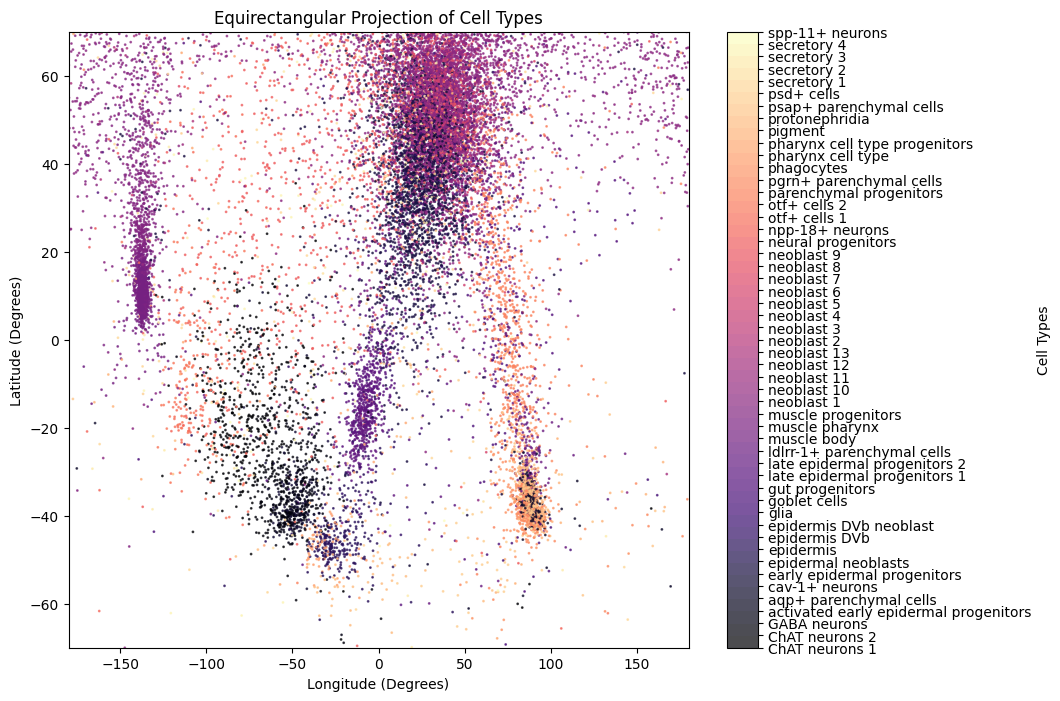

In [4]:
pc.equirectangular_projection(data, 
                              pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                              cluster_column='celltype', 
                              categories=None, 
                              selected_celltypes=None, 
                              colormap='magma', 
                              figsize=(10, 8), 
                              point_size=1, 
                              alpha=0.7, 
                              xlim=(-180, 180), 
                              ylim=(-70, 70))

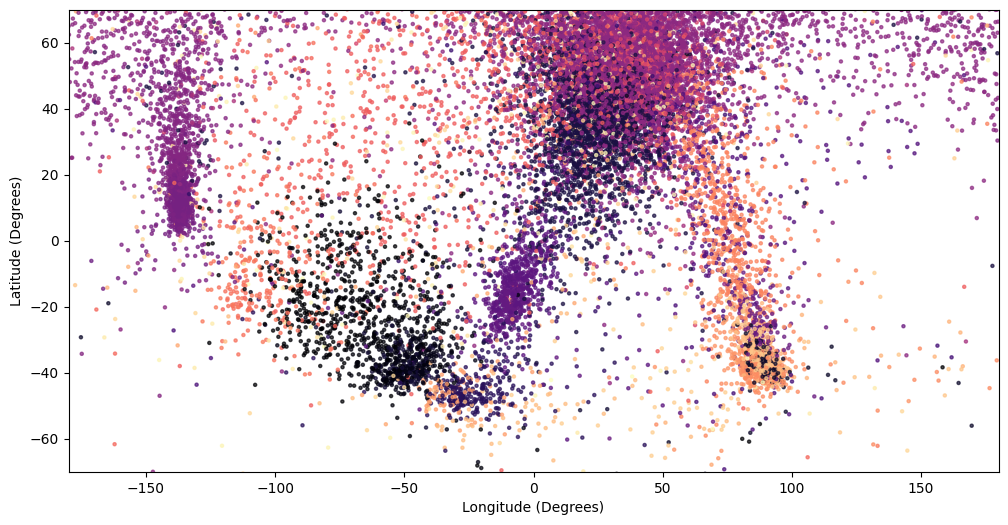

In [5]:
longitudes, latitudes = cartesian_to_spherical(data['rotated_PC1'], data['rotated_PC2'], data['rotated_PC3'])
longitudes = np.degrees(longitudes)
latitudes = np.degrees(latitudes)

data['Longitude'] = longitudes
data['Latitude'] = latitudes

celltypes = data['celltype'].astype('category').cat.codes
unique_celltypes = data['celltype'].unique() 
colormap = cm.get_cmap('magma', len(unique_celltypes))

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(data['Longitude'], data['Latitude'], c=celltypes, cmap=colormap,  s=5, alpha=0.7)
ax.set_xlabel('Longitude (Degrees)')
ax.set_ylabel('Latitude (Degrees)')
ax.set_xlim(-180, 180)
ax.set_ylim(-70, 70)

ax.grid(False)
plt.show()

/Users/lyuan13/Downloads/pca_sphere_projection\pca_sphere_projection\core.py:253: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


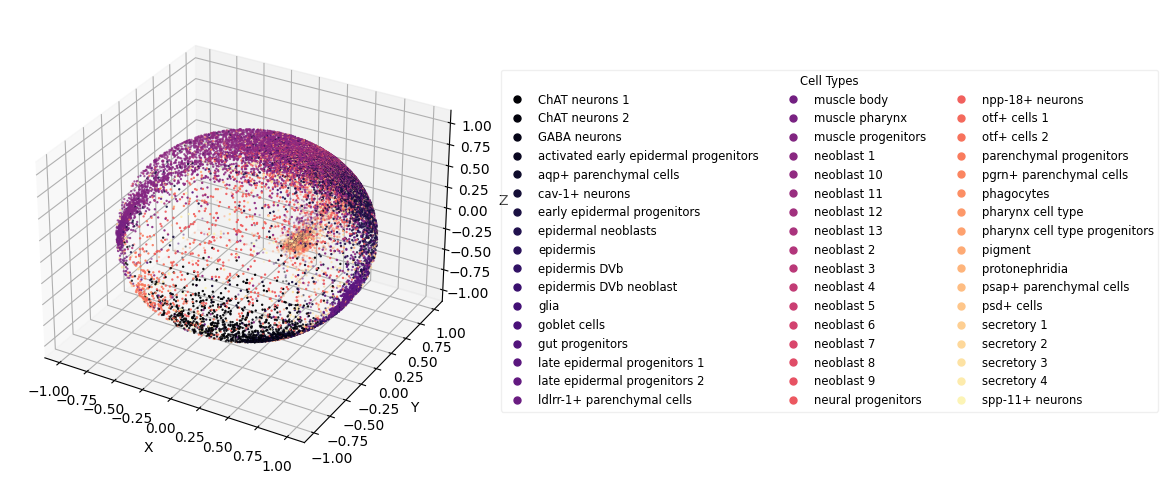

In [6]:
pc.visualize_globe( data, 
                    pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                    cluster_column='celltype', 
                    colormap='magma', 
                    point_size=0.5, 
                    interactive=False, 
                    output_html=None, 
                    figsize=(6, 6), 
                    legend_columns=3)

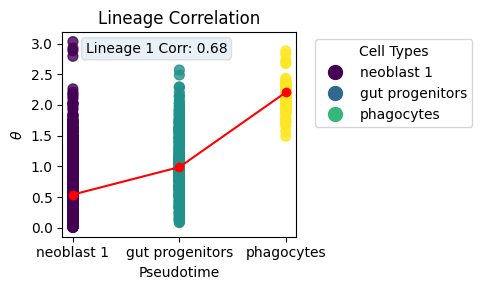

In [7]:
pc.visualize_lineage_correlation( data, 
                                  cell_types_lineage1=['neoblast 1', 'gut progenitors', 'phagocytes'], 
                                  cell_types_lineage2=None, 
                                  pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                                  cluster_column='celltype', 
                                  colormap='viridis', 
                                  figsize=(5, 3), 
                                  annotate=True)

In [8]:
######################################
# Customized plotting for aesthetics #
######################################

cell_types_of_interest = [
    'neoblast 1', 
    'epidermal neoblasts', 
    'early epidermal progenitors', 
    'late epidermal progenitors 1', 
    'late epidermal progenitors 2', 
    'epidermis'
]
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()
filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

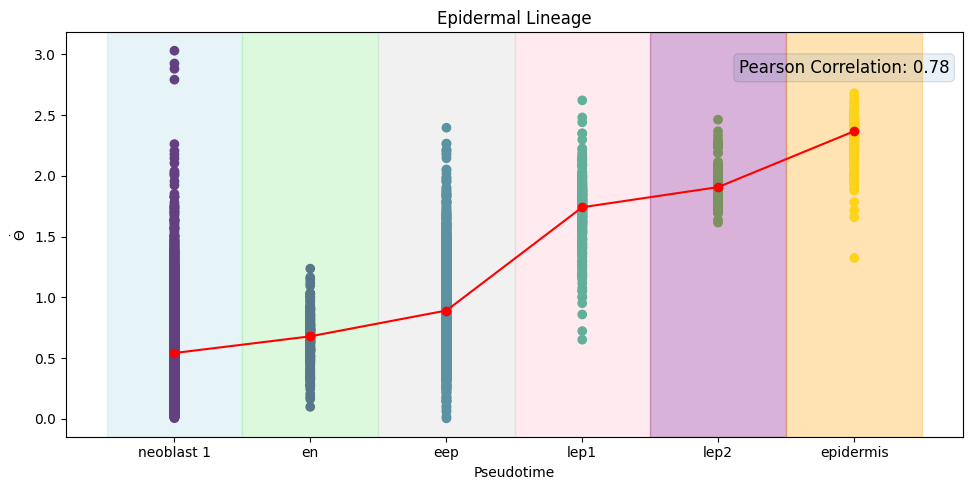

In [9]:
stages = {
    'neoblast 1': (0, 1.66),
    'epidermal neoblasts': (1.66, 3.33),
    'early epidermal progenitors': (3.33, 5),
    'late epidermal progenitors 1': (5, 6.66),
    'late epidermal progenitors 2': (6.66, 8.33),
    'epidermis': (8.33, 10)
}

category_scale = {
    'neoblast 1': 0.83,  # Average of 0 and 1.66
    'epidermal neoblasts': 2.495,  # Average of 1.66 and 3.33
    'early epidermal progenitors': 4.165,  # Average of 3.33 and 5
    'late epidermal progenitors 1': 5.83,  # Average of 5 and 6.66
    'late epidermal progenitors 2': 7.495,  # Average of 6.66 and 8.33
    'epidermis': 9.165  # Average of 8.33 and 10
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])


fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis', label='Theta vs Pseudotime')

ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'en', 'eep', 'lep1', 'lep2', 'epidermis']))

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')


colors = ['lightblue', 'lightgreen', 'lightgrey', 'pink', 'purple', 'orange']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Epidermal Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [10]:
cell_types_of_interest = ['neoblast 1', 'gut progenitors', 'phagocytes']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()


filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)
filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

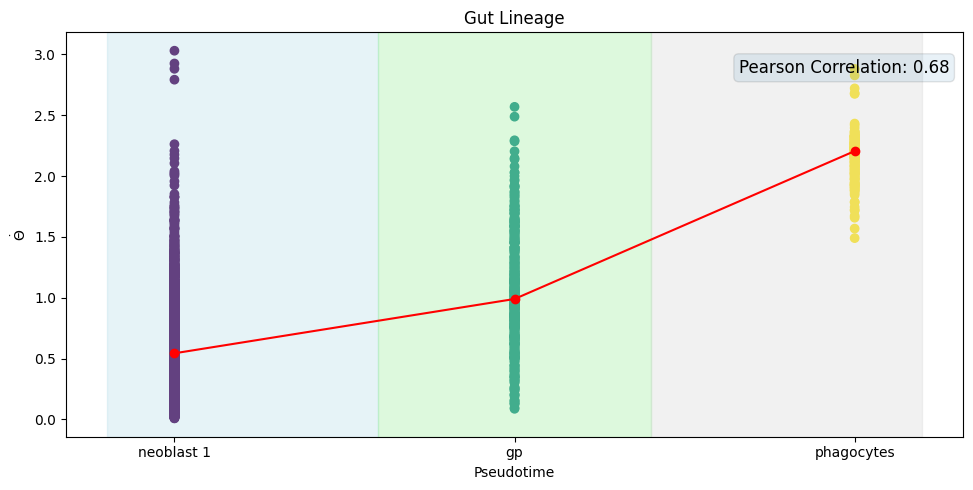

In [11]:
stages = {
    'neoblast 1': (0, 3.33),       
    'gut progenitors': (3.33, 6.67), 
    'phagocytes': (6.67, 10)        
}

category_scale = {
    'neoblast 1': 0.83,  
    'gut progenitors': 5,  
    'phagocytes': 9.17,  
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])


fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')

ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'gp', 'phagocytes']))
medians = filtered_data.groupby('celltype')['theta'].median() 
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lightblue', 'lightgreen', 'lightgrey']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Gut Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [12]:
cell_types_of_interest = ['neoblast 1', 'muscle progenitors', 'muscle body', 'muscle pharynx']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

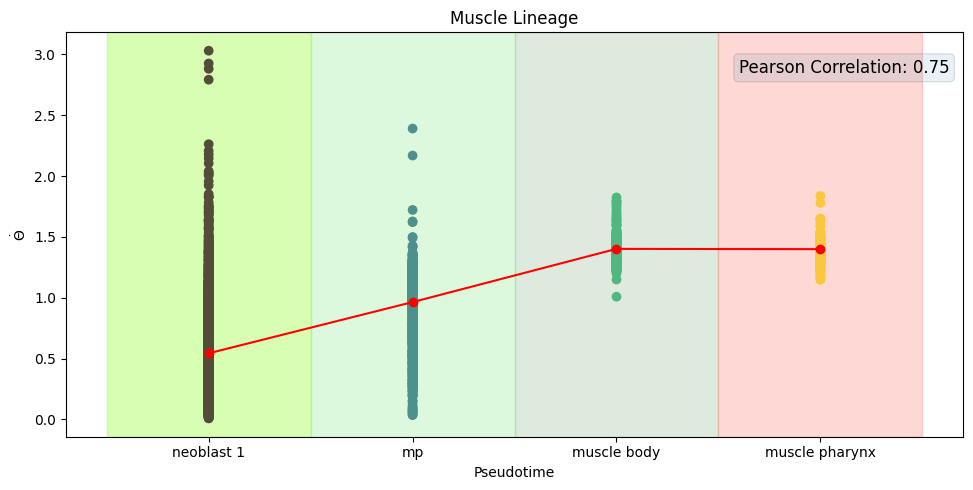

In [13]:
stages = {
    'neoblast 1': (0, 2.5),          
    'muscle progenitors': (2.5, 5),   
    'muscle body': (5, 7.5),          
    'muscle pharynx': (7.5, 10)     
}

category_scale = {
    'neoblast 1': 1.25,  
    'muscle progenitors': 3.75,  
    'muscle body': 6.25,  
    'muscle pharynx': 8.75  
}


filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'mp', 'muscle body', 'muscle pharynx']))

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lawngreen', 'lightgreen', 'darkseagreen', 'salmon']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Muscle Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [14]:
cell_types_of_interest = ['neoblast 1', 'parenchymal progenitors', 'ldlrr-1+ parenchymal cells', 'pgrn+ parenchymal cells', 'glia']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

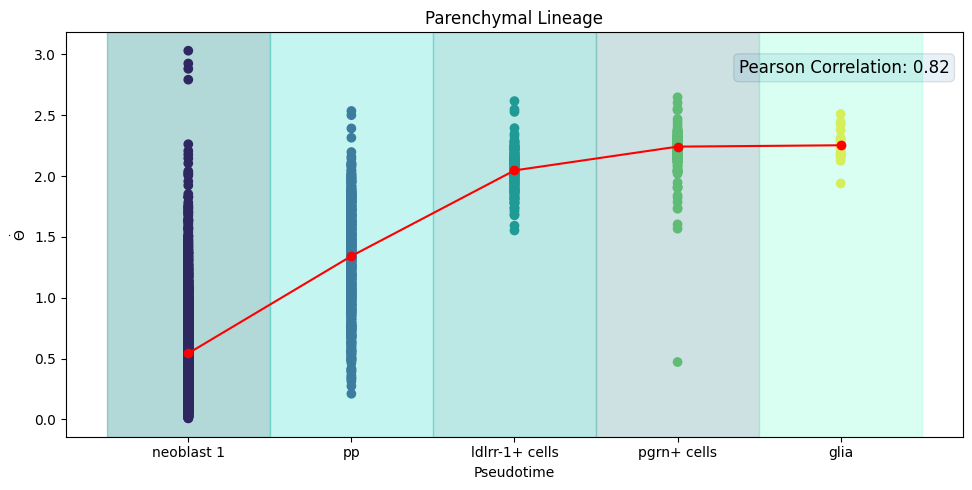

In [15]:
stages = {
    'neoblast 1': (0, 2),                     
    'parenchymal progenitors': (2, 4),      
    'ldlrr-1+ parenchymal cells': (4, 6),    
    'pgrn+ parenchymal cells': (6, 8),       
    'glia': (8, 10)                         
}

category_scale = {
    'neoblast 1': 1,                         
    'parenchymal progenitors': 3,             
    'ldlrr-1+ parenchymal cells': 5,         
    'pgrn+ parenchymal cells': 7,             
    'glia': 9                                
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'] ,
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'pp', 'ldlrr-1+ cells', 'pgrn+ cells', 'glia']))

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['teal', 'turquoise', 'lightseagreen', 'cadetblue', 'aquamarine']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Parenchymal Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [16]:
cell_types_of_interest = ['neoblast 1', 'neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2', 'GABA neurons', 'cav-1+ neurons']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

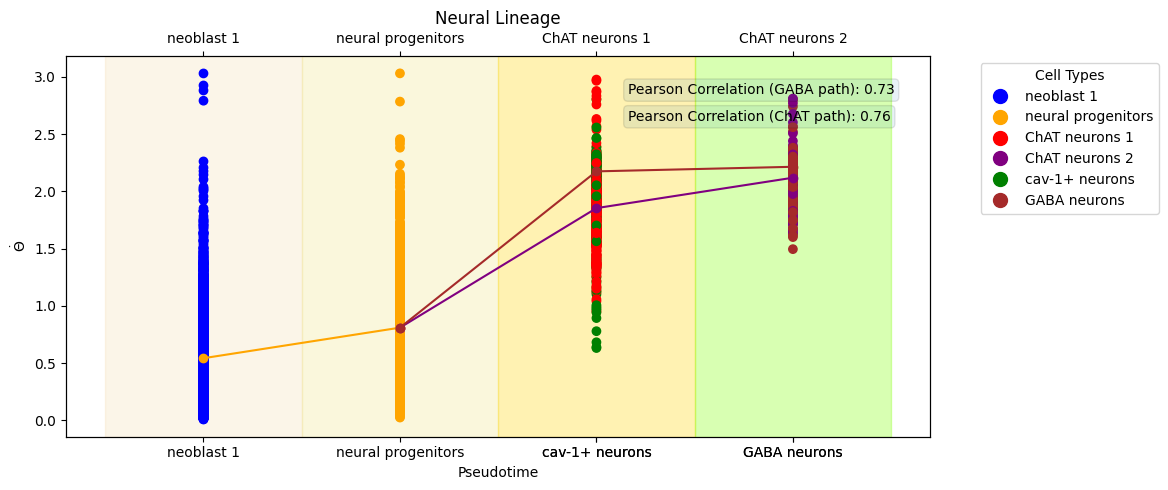

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

position_map = {'neoblast 1': 0, 'neural progenitors': 1, 'ChAT neurons 1': 2, 'ChAT neurons 2': 3,
                'cav-1+ neurons': 2, 'GABA neurons': 3}
filtered_data['position'] = filtered_data['celltype'].map(position_map)

gaba_path_data = filtered_data[filtered_data['celltype'].isin(['neoblast 1', 'neural progenitors', 'cav-1+ neurons', 'GABA neurons'])]
gaba_corr, _ = pearsonr(gaba_path_data['position'], gaba_path_data['theta'])
chat_path_data = filtered_data[filtered_data['celltype'].isin(['neoblast 1', 'neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'])]
chat_corr, _ = pearsonr(chat_path_data['position'], chat_path_data['theta'])

colors = ['wheat', 'khaki', 'gold', 'chartreuse']
ax.axvspan(0 - 0.5, 0 + 0.5, color=colors[0], alpha=0.3)
ax.axvspan(1 - 0.5, 1 + 0.5, color=colors[1], alpha=0.3)
ax.axvspan(2 - 0.5, 2 + 0.5, color=colors[2], alpha=0.3)
ax.axvspan(3 - 0.5, 3 + 0.5, color=colors[3], alpha=0.3)

color_map = {
    'neoblast 1': 'blue',
    'neural progenitors': 'orange',
    'ChAT neurons 1': 'red',
    'ChAT neurons 2': 'purple',
    'cav-1+ neurons': 'green',
    'GABA neurons': 'brown'
}

scatter = ax.scatter(
    filtered_data['position'], 
    filtered_data['theta'], 
    c=filtered_data['celltype'].map(color_map), 
    label='Theta vs Pseudotime'
)

def plot_valid_segments_custom_colors(data, groups, ax, color_map):
    for group in groups:
        group_data = data[data['celltype'].isin(group)]
        if group_data.empty:
            continue
        
        positions = [position_map[cat] for cat in group if cat in group_data['celltype'].unique()]
        medians = group_data.groupby('celltype')['theta'].median()
        valid_cats = [cat for cat in group if cat in medians.index]
        valid_medians = medians[valid_cats].values
        valid_positions = [position_map[cat] for cat in valid_cats]
        
        if len(valid_medians) > 1:
            ax.plot(valid_positions, valid_medians, 'o-', label=' to '.join(valid_cats), color=color_map[valid_cats[-1]])

groups = [
    ['neoblast 1', 'neural progenitors'],
    ['neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'],
    ['neural progenitors', 'cav-1+ neurons', 'GABA neurons']
]

plot_valid_segments_custom_colors(filtered_data, groups, ax, color_map)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Neural Lineage')

ax.set_xticks(list(position_map.values()))
ax.set_xticklabels(list(position_map.keys()))


ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(['neoblast 1', 'neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'])

ax.annotate(f'Pearson Correlation (GABA path): {gaba_corr:.2f}', xy=(0.65, 0.90), xycoords='axes fraction', fontsize=10, bbox=dict(boxstyle="round", alpha=0.1))
ax.annotate(f'Pearson Correlation (ChAT path): {chat_corr:.2f}', xy=(0.65, 0.83), xycoords='axes fraction', fontsize=10, bbox=dict(boxstyle="round", alpha=0.1))

handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10, label=celltype) 
           for celltype, color in color_map.items()]
ax.legend(handles=handles, title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

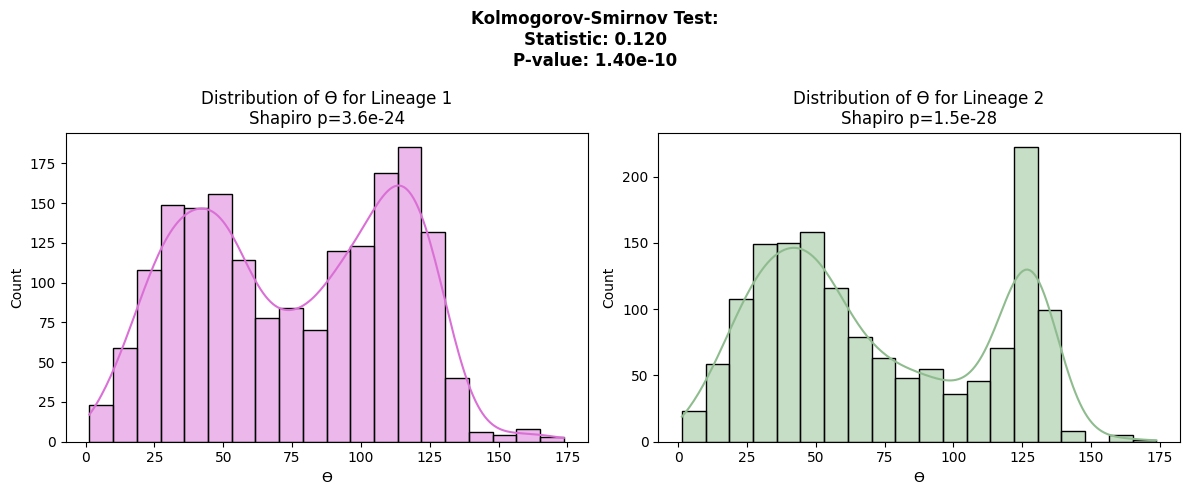

{'test_type': 'Kolmogorov-Smirnov Test',
 'test_statistic': 0.11957195190173421,
 'p_value': 1.3957357491989342e-10}

In [18]:
pc.statistical_test_on_lineages(  data, 
                                  lineage1=['neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'], 
                                  lineage2=['neural progenitors', 'cav-1+ neurons', 'GABA neurons'], 
                                  pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                                  cluster_column='celltype', 
                                  figsize=(12, 5))

In [19]:
cell_types_of_interest = ['phagocytes', 'glia',  'muscle pharynx', 'epidermis', 'ChAT neurons 2', 'GABA neurons']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

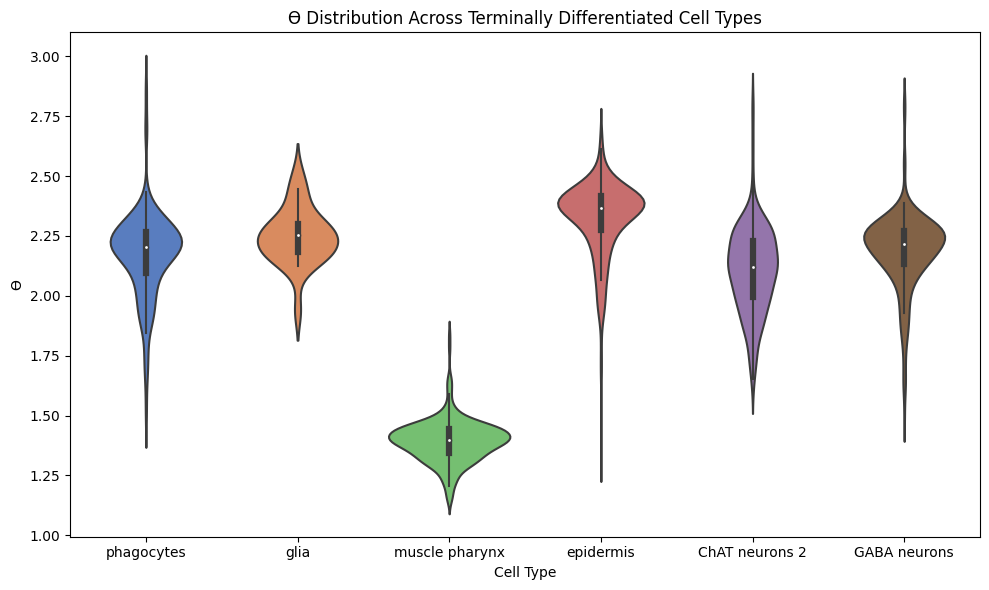

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='celltype', y='theta', data=filtered_data, palette='muted')

plt.xlabel('Cell Type')
plt.ylabel('ϴ')
plt.title('ϴ Distribution Across Terminally Differentiated Cell Types')
plt.xticks()
plt.tight_layout()
plt.show()

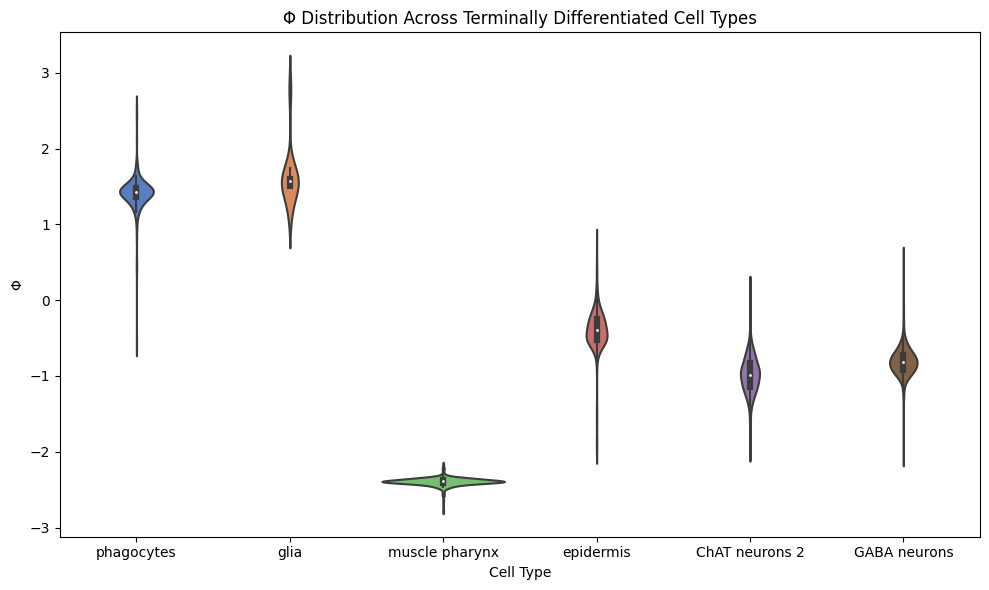

In [21]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='celltype', y='phi', data=filtered_data, palette='muted')

plt.xlabel('Cell Type')
plt.ylabel('Φ')
plt.title('Φ Distribution Across Terminally Differentiated Cell Types')
plt.xticks()
plt.tight_layout()
plt.show()

In [22]:
# Load the CSV file
df = pd.read_csv('Planaria.csv')
#
pc_columns = df.columns[:50]
pcs = df[pc_columns]
# Normalize the principal components to project them onto a 50-dimensional unit sphere
# This involves dividing each vector by its norm
norms = np.linalg.norm(pcs, axis=1)
pcs_normalized = pcs.div(norms, axis=0)
# Combine the normalized PCs back into the dataframe
df_normalized = df.copy()
df_normalized[pc_columns] = pcs_normalized

FileNotFoundError: [Errno 2] No such file or directory: 'Planaria.csv'

In [120]:
def rotate_to_north_pole_H(points, centroid):
    # Normalize the centroid
    norm_centroid = np.linalg.norm(centroid)
    if norm_centroid == 0:
        raise ValueError("Centroid has zero magnitude, cannot perform rotation.")
    
    centroid = centroid / norm_centroid
    
    # Define the north pole in n-dimensional space
    north_pole = np.zeros_like(centroid)
    north_pole[-1] = 1  # Last coordinate is 1, others are 0

    # Calculate the Householder reflection matrix
    v = centroid - north_pole
    v = v / np.linalg.norm(v)  # Normalize the reflection vector

    # Compute the Householder reflection matrix: H = I - 2 * vv^T
    I = np.identity(len(centroid))
    H = I - 2 * np.outer(v, v)
    
    # Rotate the points by applying the Householder transformation
    rotated_points = np.dot(points, H.T)
    
    return rotated_points

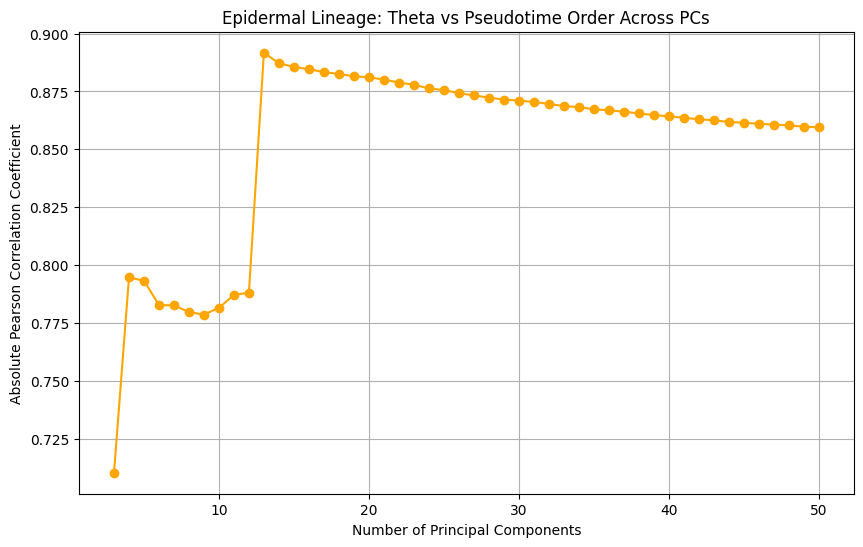

In [122]:
# Filter the dataset to focus on the specified cell types
cell_types_of_interest = [
    'neoblast 1', 
    'epidermal neoblasts', 
    'early epidermal progenitors', 
    'late epidermal progenitors 1', 
    'late epidermal progenitors 2', 
    'epidermis'
]

filtered_df = df_normalized[df_normalized['labels'].isin(cell_types_of_interest)]

# Define a function to calculate theta for n-dimensional space
def calculate_spherical_theta(coordinates):
    r = np.linalg.norm(coordinates)
    theta = np.arccos(coordinates[-1] / r)  # angle from the last axis (z-axis in 3D)
    return theta

# Calculate the Pearson correlation coefficient for theta vs pseudotime order for n = 3 to 50
results = []

# Create a pseudotime order based on the order of cell_types_of_interest
pseudotime_order = filtered_df['labels'].apply(lambda x: cell_types_of_interest.index(x)).values

for n in range(3, 51):
    # Select the first n PCs
    selected_pcs = filtered_df[pc_columns[:n]].values
    # Find the centroid of 'neoblast 1' points
    centroid = np.mean(filtered_df[filtered_df['labels'] == 'neoblast 1'][pc_columns[:n]].values, axis=0)
    
    # Rotate the points to align the centroid with the north pole
    rotated_points = rotate_to_north_pole_H(selected_pcs, centroid)
    
    # Normalize to ensure the points are projected onto an n-dimensional unit ball
    norms = np.linalg.norm(rotated_points, axis=1)
    normalized_points = rotated_points / norms[:, np.newaxis]
    
    # Calculate theta for each cell
    thetas = np.apply_along_axis(calculate_spherical_theta, 1, normalized_points)
    
    # Calculate the Pearson correlation coefficient between theta and pseudotime order
    correlation, _ = pearsonr(thetas, pseudotime_order)
    
    # Store the result
    results.append((n, correlation))

# Convert results to a DataFrame for easier viewing
results_df = pd.DataFrame(results, columns=['Number of PCs', 'Pearson Correlation'])
#
plt.figure(figsize=(10, 6))
plt.plot(results_df['Number of PCs'], np.abs(results_df['Pearson Correlation']), marker='o', color='orange')
plt.title('Epidermal Lineage: Theta vs Pseudotime Order Across PCs')
plt.xlabel('Number of Principal Components')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.grid(True)
plt.show()

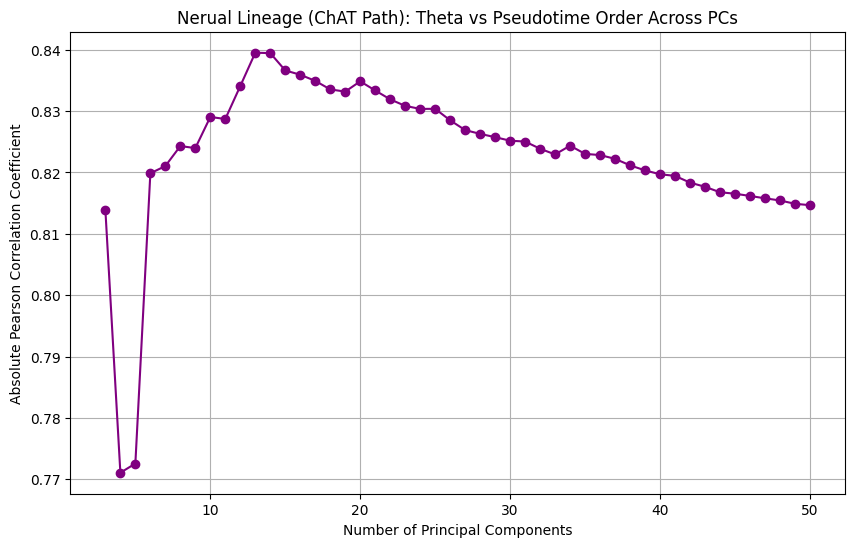

In [123]:
new_cell_types_of_interest = [
    'neoblast 1', 
    'neural progenitors', 
    'ChAT neurons 1', 
    'ChAT neurons 2'
]

# Filter the dataset for the new set of cell types
new_filtered_df = df_normalized[df_normalized['labels'].isin(new_cell_types_of_interest)]

# Create a new pseudotime order based on the order of new_cell_types_of_interest
new_pseudotime_order = new_filtered_df['labels'].apply(lambda x: new_cell_types_of_interest.index(x)).values

# Calculate the Pearson correlation coefficient for theta vs pseudotime order for n = 3 to 50
new_results = []

for n in range(3, 51):
    # Select the first n PCs
    selected_pcs = new_filtered_df[pc_columns[:n]].values
    
    # Find the centroid of 'neoblast 1' points
    centroid = np.mean(new_filtered_df[new_filtered_df['labels'] == 'neoblast 1'][pc_columns[:n]].values, axis=0)
    
    # Rotate the points to align the centroid with the north pole
    rotated_points = rotate_to_north_pole_H(selected_pcs, centroid)
    
    # Normalize to ensure the points are projected onto an n-dimensional unit ball
    norms = np.linalg.norm(rotated_points, axis=1)
    normalized_points = rotated_points / norms[:, np.newaxis]
    
    # Calculate theta for each cell
    thetas = np.apply_along_axis(calculate_spherical_theta, 1, normalized_points)
    
    # Calculate the Pearson correlation coefficient between theta and pseudotime order
    correlation, _ = pearsonr(thetas, new_pseudotime_order)
    
    # Store the result
    new_results.append((n, correlation))

# Convert new results to a DataFrame
new_results_df = pd.DataFrame(new_results, columns=['Number of PCs', 'Pearson Correlation'])

# Plot the absolute value of the Pearson correlation coefficients for the new set of cell types
plt.figure(figsize=(10, 6))
plt.plot(new_results_df['Number of PCs'], np.abs(new_results_df['Pearson Correlation']), marker='o', color='purple')
plt.title('Nerual Lineage (ChAT Path): Theta vs Pseudotime Order Across PCs')
plt.xlabel('Number of Principal Components')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.grid(True)
plt.show()

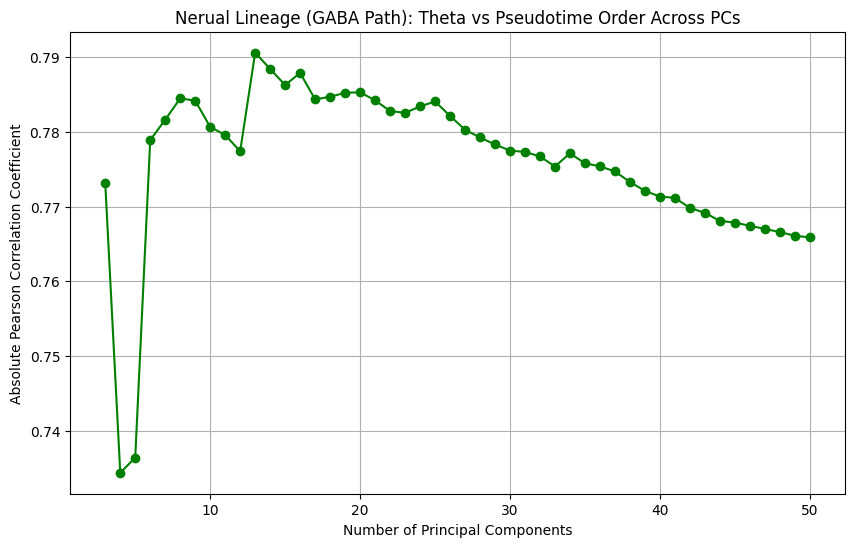

In [124]:
# Define the new set of cell types of interest
newest_cell_types_of_interest = [
    'neoblast 1', 
    'neural progenitors', 
    'cav-1+ neurons', 
    'GABA neurons'
]

# Filter the dataset for the newest set of cell types
newest_filtered_df = df_normalized[df_normalized['labels'].isin(newest_cell_types_of_interest)]

# Create a new pseudotime order based on the order of newest_cell_types_of_interest
newest_pseudotime_order = newest_filtered_df['labels'].apply(lambda x: newest_cell_types_of_interest.index(x)).values

# Calculate the Pearson correlation coefficient for theta vs pseudotime order for n = 3 to 50
newest_results = []

for n in range(3, 51):
    # Select the first n PCs
    selected_pcs = newest_filtered_df[pc_columns[:n]].values
    
    # Find the centroid of 'neoblast 1' points
    centroid = np.mean(newest_filtered_df[newest_filtered_df['labels'] == 'neoblast 1'][pc_columns[:n]].values, axis=0)
    
    # Rotate the points to align the centroid with the north pole
    rotated_points = rotate_to_north_pole_H(selected_pcs, centroid)
    
    # Normalize to ensure the points are projected onto an n-dimensional unit ball
    norms = np.linalg.norm(rotated_points, axis=1)
    normalized_points = rotated_points / norms[:, np.newaxis]
    
    # Calculate theta for each cell
    thetas = np.apply_along_axis(calculate_spherical_theta, 1, normalized_points)
    
    # Calculate the Pearson correlation coefficient between theta and pseudotime order
    correlation, _ = pearsonr(thetas, newest_pseudotime_order)
    
    # Store the result
    newest_results.append((n, correlation))

# Convert newest results to a DataFrame
newest_results_df = pd.DataFrame(newest_results, columns=['Number of PCs', 'Pearson Correlation'])

# Plot the absolute value of the Pearson correlation coefficients for the newest set of cell types
plt.figure(figsize=(10, 6))
plt.plot(newest_results_df['Number of PCs'], np.abs(newest_results_df['Pearson Correlation']), marker='o', color='green')
plt.title('Nerual Lineage (GABA Path): Theta vs Pseudotime Order Across PCs')
plt.xlabel('Number of Principal Components')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.grid(True)
plt.show()


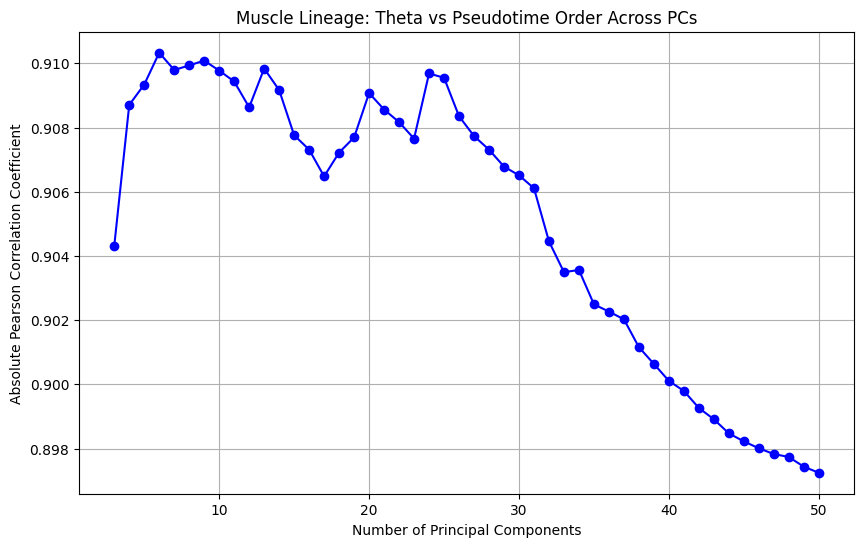

In [125]:
# Define the new set of cell types of interest
final_cell_types_of_interest = [
    'neoblast 1', 
    'muscle progenitors', 
    'muscle body', 
    'muscle pharynx'
]

# Filter the dataset for the final set of cell types
final_filtered_df = df_normalized[df_normalized['labels'].isin(final_cell_types_of_interest)]

# Create a new pseudotime order based on the order of final_cell_types_of_interest
final_pseudotime_order = final_filtered_df['labels'].apply(lambda x: final_cell_types_of_interest.index(x)).values

# Calculate the Pearson correlation coefficient for theta vs pseudotime order for n = 3 to 50
final_results = []

for n in range(3, 51):
    # Select the first n PCs
    selected_pcs = final_filtered_df[pc_columns[:n]].values
    
    # Find the centroid of 'neoblast 1' points
    centroid = np.mean(final_filtered_df[final_filtered_df['labels'] == 'neoblast 1'][pc_columns[:n]].values, axis=0)
    
    # Rotate the points to align the centroid with the north pole
    rotated_points = rotate_to_north_pole_H(selected_pcs, centroid)
    
    # Normalize to ensure the points are projected onto an n-dimensional unit ball
    norms = np.linalg.norm(rotated_points, axis=1)
    normalized_points = rotated_points / norms[:, np.newaxis]
    
    # Calculate theta for each cell
    thetas = np.apply_along_axis(calculate_spherical_theta, 1, normalized_points)
    
    # Calculate the Pearson correlation coefficient between theta and pseudotime order
    correlation, _ = pearsonr(thetas, final_pseudotime_order)
    
    # Store the result
    final_results.append((n, correlation))

# Convert final results to a DataFrame
final_results_df = pd.DataFrame(final_results, columns=['Number of PCs', 'Pearson Correlation'])

# Plot the absolute value of the Pearson correlation coefficients for the final set of cell types
plt.figure(figsize=(10, 6))
plt.plot(final_results_df['Number of PCs'], np.abs(final_results_df['Pearson Correlation']), marker='o', color='blue')
plt.title('Muscle Lineage: Theta vs Pseudotime Order Across PCs')
plt.xlabel('Number of Principal Components')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.grid(True)
plt.show()


In [115]:
data.head()

,PC1,PC2,PC3,celltype,rotated_PC1,rotated_PC2,rotated_PC3,Longitude,Latitude
0,-0.303720,-0.899164,-0.315053,secretory 1,-0.878002,-0.419436,0.230619,-154.465433,13.333539
1,-0.493234,-0.845912,-0.202861,secretory 1,-0.784624,-0.559789,0.266462,-144.494093,15.453850
2,-0.410223,-0.763049,0.499473,secretory 1,-0.605749,-0.791115,-0.084877,-127.440936,-4.868924
3,0.812458,-0.522205,-0.259257,psap+ parenchymal cells,-0.219454,0.832074,-0.509404,104.774954,-30.624117
4,0.140406,0.548017,0.824599,late epidermal progenitors 1,0.842783,-0.055647,-0.535369,-3.777593,-32.368931


<Figure size 1800x1800 with 0 Axes>

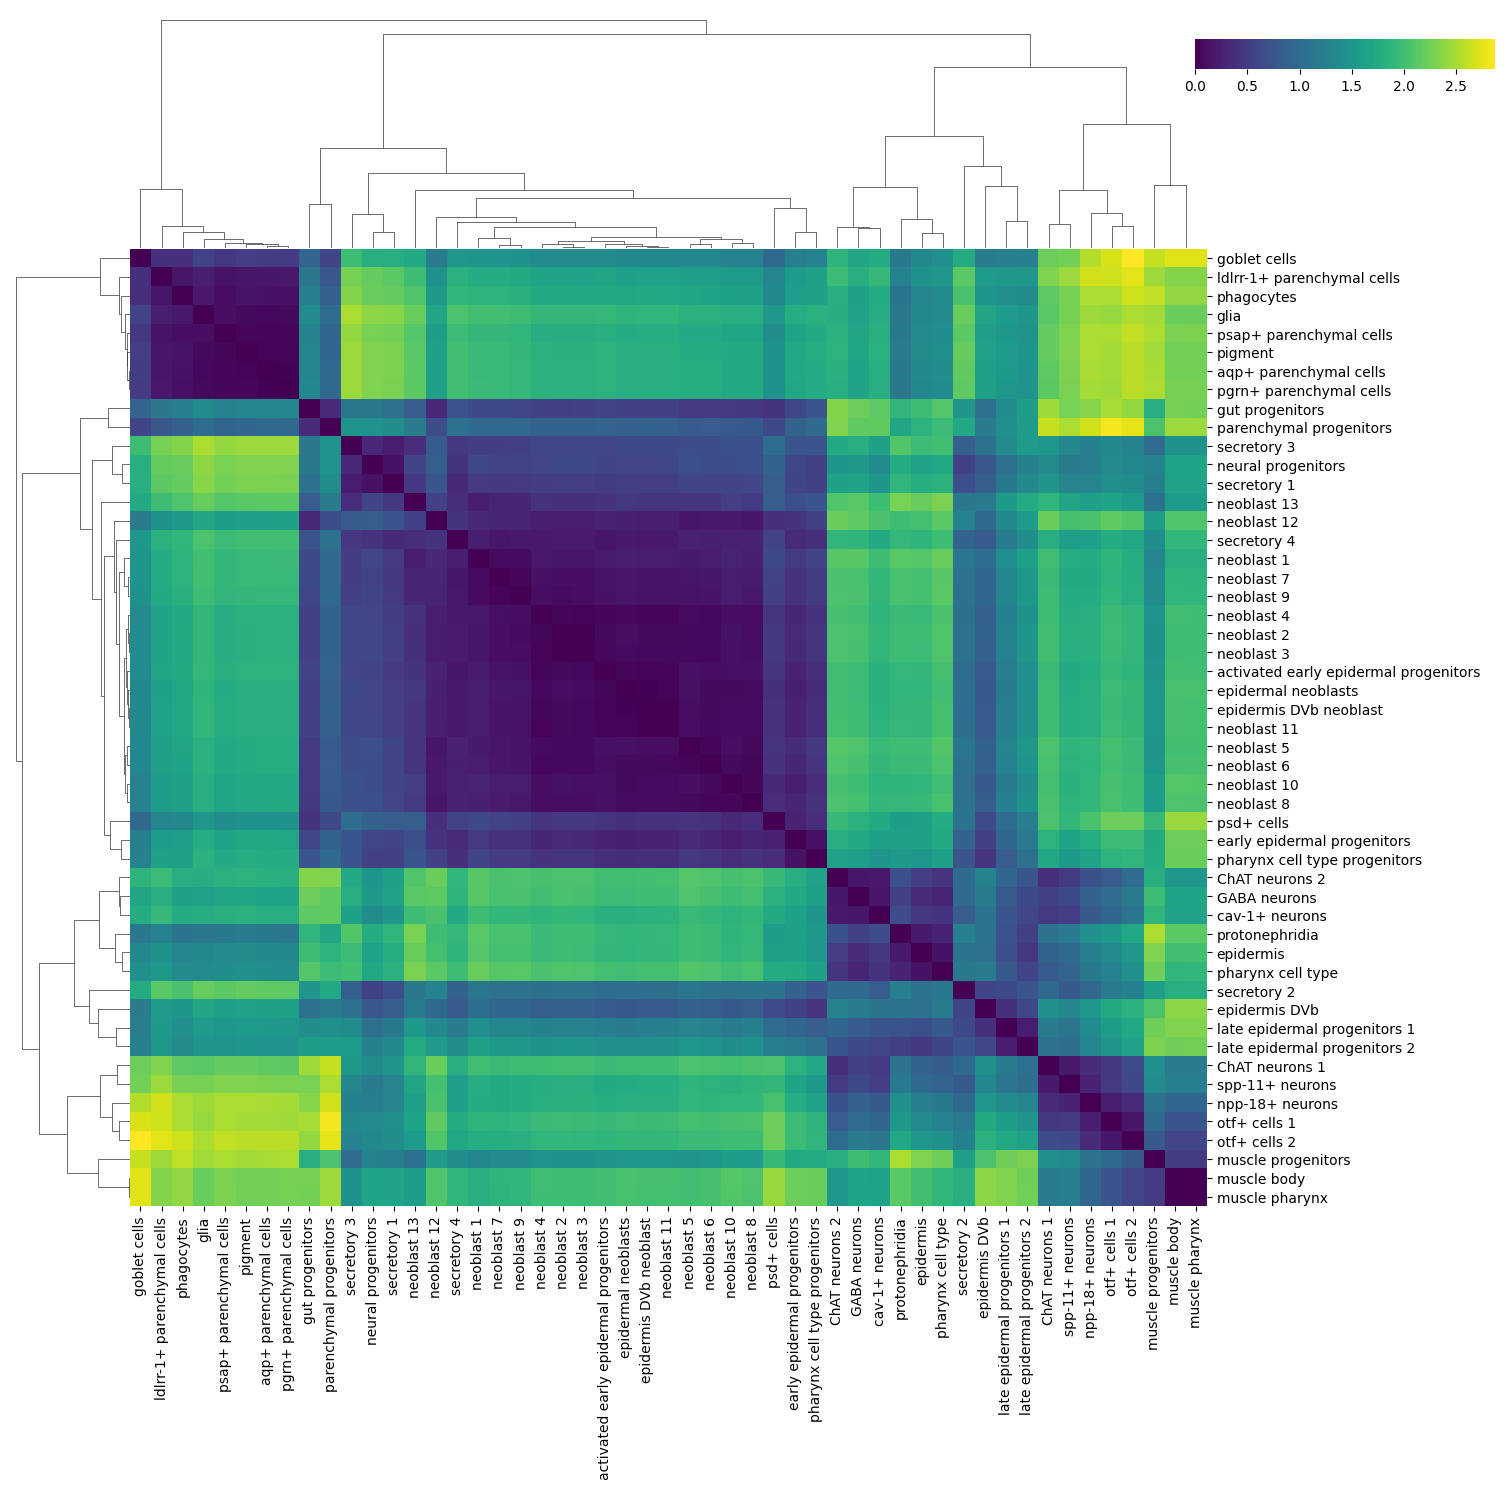

In [117]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean vector (subspace) for each category
subspaces = data.groupby('celltype')[['rotated_PC1', 'rotated_PC2', 'rotated_PC3']].mean()

# Calculate the cosine similarity between all subspaces
cosine_distances = pdist(subspaces, metric='cosine')

# Convert the cosine distances to an angular distance matrix
angular_distances = np.arccos(1 - cosine_distances)
angular_distance_matrix = squareform(angular_distances)

# Perform hierarchical clustering
linkage_matrix = linkage(angular_distances, method='average')

# Plot the heatmap with hierarchical clustering
plt.figure(figsize=(18, 18))
g =sns.clustermap(angular_distance_matrix, row_linkage=linkage_matrix, col_linkage=linkage_matrix, 
               cmap='viridis', figsize=(15, 15), xticklabels=subspaces.index, yticklabels=subspaces.index,
               cbar_pos=(0.8, 0.95, 0.2, 0.02),  # Position the color bar in the upper right corner (left, bottom, width, height),
               dendrogram_ratio=(0.1, 0.2), cbar_kws={'orientation': 'horizontal'})
#plt.title('Hierarchical Clustering of Angular Relationships Between Subspaces of Cell Categories')
#plt.tight_layout()
plt.show()
g.savefig('clustermap_plot2.png') 

<Figure size 1800x1800 with 0 Axes>

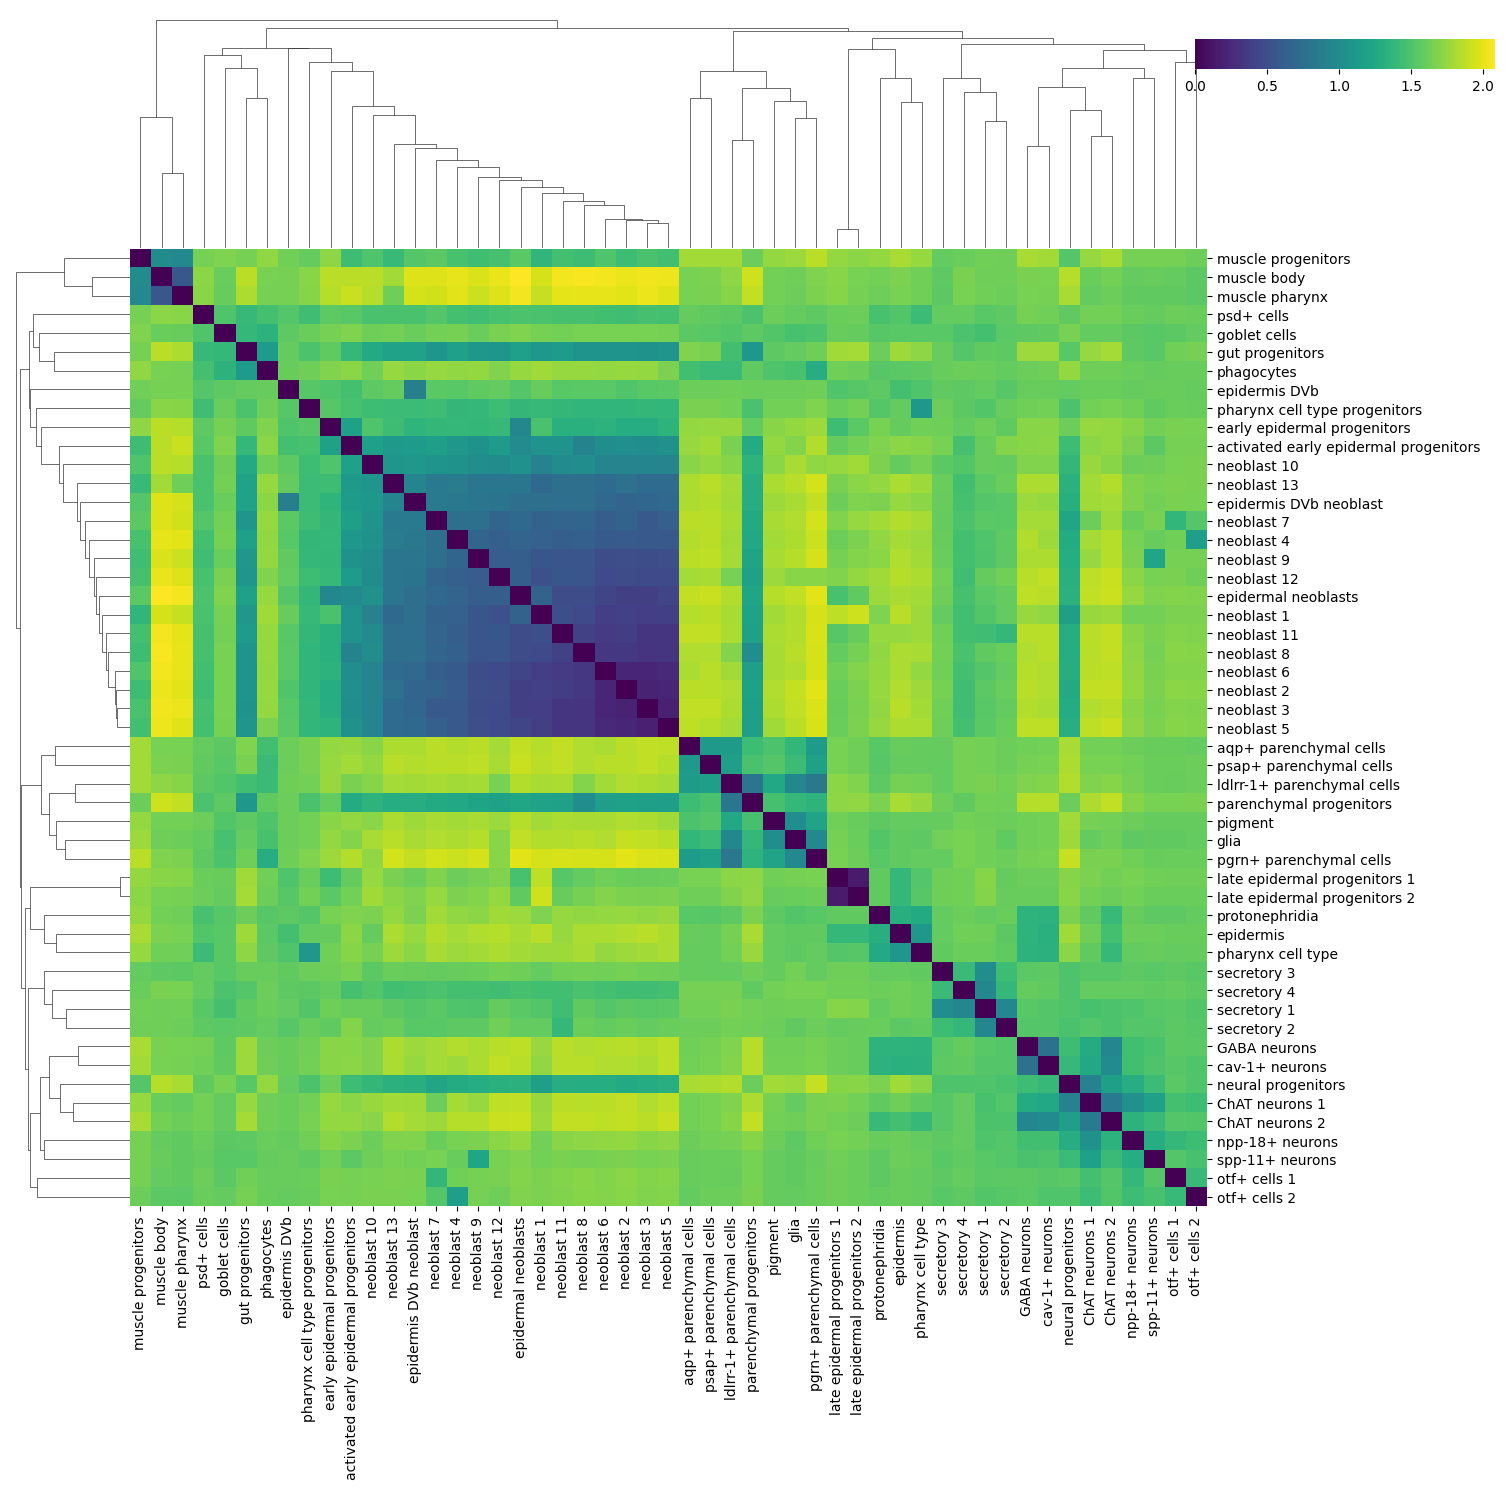

In [22]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean vector (subspace) for each category
subspaces = df.groupby('labels')[df.columns[:50]].mean()

# Calculate the cosine similarity between all subspaces
cosine_distances = pdist(subspaces, metric='cosine')

# Convert the cosine distances to an angular distance matrix
angular_distances = np.arccos(1 - cosine_distances)
angular_distance_matrix = squareform(angular_distances)

# Perform hierarchical clustering
linkage_matrix = linkage(angular_distances, method='average')

# Plot the heatmap with hierarchical clustering
plt.figure(figsize=(18, 18))
g =sns.clustermap(angular_distance_matrix, row_linkage=linkage_matrix, col_linkage=linkage_matrix, 
               cmap='viridis', figsize=(15, 15), xticklabels=subspaces.index, yticklabels=subspaces.index,
               cbar_pos=(0.8, 0.95, 0.2, 0.02),  # Position the color bar in the upper right corner (left, bottom, width, height),
               dendrogram_ratio=(0.1, 0.2), cbar_kws={'orientation': 'horizontal'})
#plt.title('Hierarchical Clustering of Angular Relationships Between Subspaces of Cell Categories')
#plt.tight_layout()
plt.show()
g.savefig('clustermap_plot.png') 

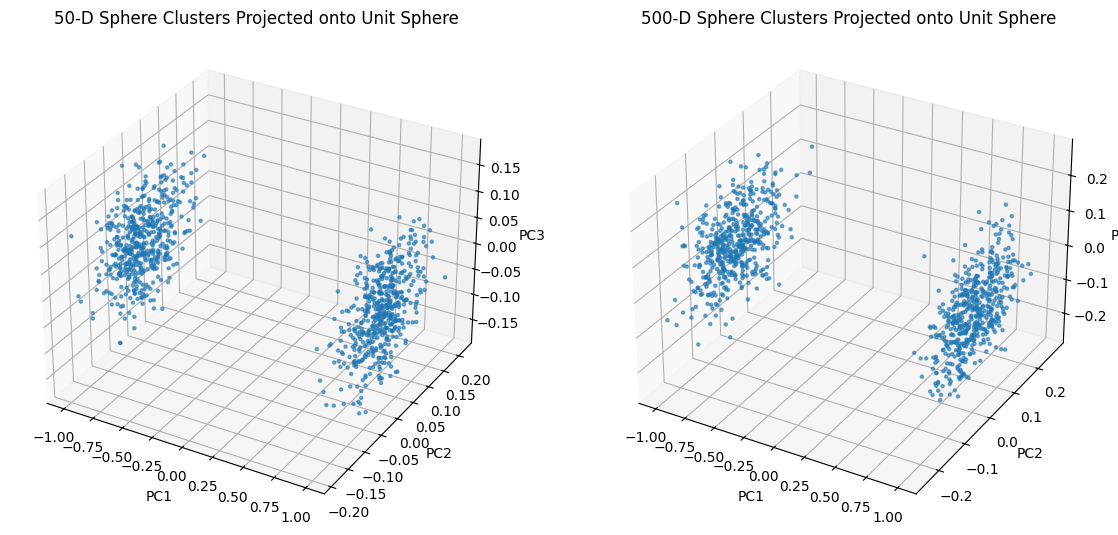

In [25]:
from sklearn.decomposition import PCA

# Function to project onto unit sphere
def project_onto_unit_sphere(data):
    norm = np.linalg.norm(data, axis=1).reshape(-1, 1)
    return data / norm

# Function to generate tight clusters around specific centers on a unit sphere
def generate_tight_clusters_on_sphere(dim, n_samples, center1, center2, std):
    # Generate points around the first center
    cluster1 = np.random.normal(loc=center1, scale=std, size=(n_samples // 2, dim))
    cluster1 = project_onto_unit_sphere(cluster1)
    
    # Generate points around the second center
    cluster2 = np.random.normal(loc=center2, scale=std, size=(n_samples // 2, dim))
    cluster2 = project_onto_unit_sphere(cluster2)
    
    # Combine the clusters
    return np.vstack((cluster1, cluster2))

# Step 1: Define far-apart cluster centers on unit spheres
center1_50 = np.array([1] + [0]*49)  # Center near the "north pole" in 50D
center2_50 = np.array([-1] + [0]*49)  # Center near the "south pole" in 50D

center1_500 = np.array([1] + [0]*499)  # Center near the "north pole" in 500D
center2_500 = np.array([-1] + [0]*499)  # Center near the "south pole" in 500D

# Step 2: Sample populations with tight clusters on the unit spheres
pop_50_sphere_clusters = generate_tight_clusters_on_sphere(50, 1000, center1_50, center2_50, std=0.05)
pop_500_sphere_clusters = generate_tight_clusters_on_sphere(500, 1000, center1_500, center2_500, std=0.05)

# Step 3: Reduce dimensionality to first three PCs
pca_pop_50_clusters = PCA(n_components=3)
pca_pop_500_clusters = PCA(n_components=3)

pop_50_reduced_clusters = pca_pop_50_clusters.fit_transform(pop_50_sphere_clusters)
pop_500_reduced_clusters = pca_pop_500_clusters.fit_transform(pop_500_sphere_clusters)

# Project onto unit sphere
pop_50_reduced_sphere_clusters = project_onto_unit_sphere(pop_50_reduced_clusters)
pop_500_reduced_sphere_clusters = project_onto_unit_sphere(pop_500_reduced_clusters)

# Step 4: Plot side-by-side comparisons
fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(pop_50_reduced_sphere_clusters[:, 0], pop_50_reduced_sphere_clusters[:, 1], pop_50_reduced_sphere_clusters[:, 2], alpha=0.6, s=5)
ax1.set_title('50-D Sphere Clusters Projected onto Unit Sphere')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(pop_500_reduced_sphere_clusters[:, 0], pop_500_reduced_sphere_clusters[:, 1], pop_500_reduced_sphere_clusters[:, 2], alpha=0.6, s=5)
ax2.set_title('500-D Sphere Clusters Projected onto Unit Sphere')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

plt.show()


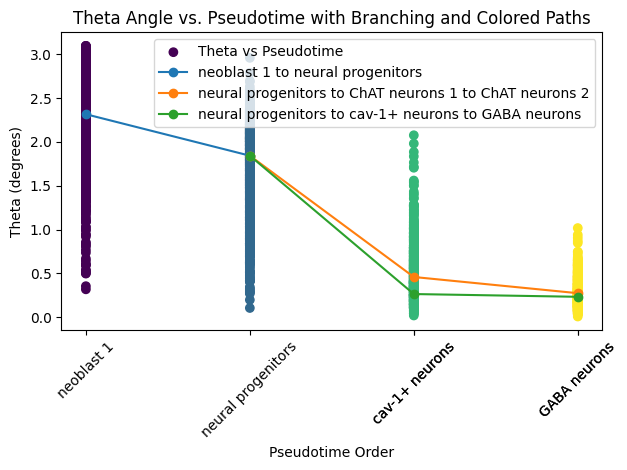

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

# Define proper positions for x-axis
position_map = {'neoblast 1': 0, 'neural progenitors': 1, 'ChAT neurons 1': 2, 'ChAT neurons 2': 3,
                'cav-1+ neurons': 2, 'GABA neurons': 3}
filtered_data['position'] = filtered_data['celltype'].map(position_map)

# Scatter plot
scatter = ax.scatter(filtered_data['position'], filtered_data['theta'], c=filtered_data['position'], cmap='viridis', label='Theta vs Pseudotime')
#ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=key) for key, color in color_map.items()])

def plot_valid_segments(data, groups, ax):
    for group in groups:
        # Filter data for the current group
        group_data = data[data['celltype'].isin(group)]
        if group_data.empty:
            continue
        
        # Calculate positions and medians
        positions = [position_map[cat] for cat in group if cat in group_data['celltype'].unique()]
        medians = group_data.groupby('celltype')['theta'].median()
        valid_cats = [cat for cat in group if cat in medians.index]
        valid_medians = medians[valid_cats].values
        valid_positions = [position_map[cat] for cat in valid_cats]
        
        # Plot lines if sufficient data is available
        if len(valid_medians) > 1:
            ax.plot(valid_positions, valid_medians, 'o-',  label=' to '.join(valid_cats))

# Groups to be plotted with branching
groups = [
    ['neoblast 1', 'neural progenitors'],
    ['neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'],
    ['neural progenitors', 'cav-1+ neurons', 'GABA neurons']
]

plot_valid_segments(filtered_data, groups, ax)

ax.set_xlabel('Pseudotime Order')
ax.set_ylabel('Theta (degrees)')
ax.set_title('Theta Angle vs. Pseudotime with Branching and Colored Paths')
ax.set_xticks(list(position_map.values()))
ax.set_xticklabels(list(position_map.keys()), rotation=45)
plt.legend()
plt.tight_layout()  # Adjust layout to make room for legend if necessary
plt.show()